# Análise exploratória da cesta básica no Brasil

Este notebook organiza uma análise exploratória dos dados da Pesquisa Nacional da Cesta Básica de Alimentos, com foco na evolução do preço da cesta básica e das horas de trabalho necessárias para sua aquisição em capitais da região Sudeste.

## Objetivo

Analisar a variação histórica do custo da cesta básica e comparar o comportamento dos indicadores entre São Paulo, Rio de Janeiro, Belo Horizonte e Vitória.

## Escopo da análise

A análise utiliza dois conjuntos de dados tratados previamente:

- `data/processed/preco_cesta.csv`
- `data/processed/horas_trabalho.csv`

Os gráficos principais priorizam o período de 1995 a 2024, pois o período anterior é fortemente afetado pela hiperinflação e dificulta a leitura visual dos dados em escala linear.

## Carregamento dos dados tratados

Nesta etapa, são carregados os arquivos tratados gerados pelo pipeline de processamento em Python.

O notebook utiliza caminhos relativos à raiz do projeto, permitindo que a análise funcione tanto no ambiente local quanto em outros computadores após o clone do repositório.

In [1]:
from pathlib import Path

import pandas as pd


# Detecta a raiz do projeto mesmo que o notebook esteja dentro da pasta notebooks/
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

HORAS_PATH = PROJECT_ROOT / "data" / "processed" / "horas_trabalho.csv"
PRECOS_PATH = PROJECT_ROOT / "data" / "processed" / "preco_cesta.csv"

horas = pd.read_csv(HORAS_PATH)
precos = pd.read_csv(PRECOS_PATH)

print("Raiz do projeto:", PROJECT_ROOT)
print("Arquivo horas:", HORAS_PATH)
print("Arquivo preços:", PRECOS_PATH)

print("\nHoras de trabalho:")
display(horas.head())

print("\nPreço da cesta:")
display(precos.head())

print("\nDimensões:")
print("horas:", horas.shape)
print("preços:", precos.shape)

Raiz do projeto: C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil
Arquivo horas: C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\data\processed\horas_trabalho.csv
Arquivo preços: C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\data\processed\preco_cesta.csv

Horas de trabalho:


,mes_ano,valor_original,cidade,metrica,valor_minutos
0,01-1989,154h45m,São Paulo,horas_trabalho,9285.0
1,02-1989,176h22m,São Paulo,horas_trabalho,10582.0
2,03-1989,194h21m,São Paulo,horas_trabalho,11661.0
3,04-1989,207h03m,São Paulo,horas_trabalho,12423.0
4,05-1989,197h01m,São Paulo,horas_trabalho,11821.0



Preço da cesta:


,mes_ano,valor_original,cidade,metrica,valor_reais
0,01-1989,44.95,São Paulo,preco_cesta,44.95
1,02-1989,51.23,São Paulo,preco_cesta,51.23
2,03-1989,56.45,São Paulo,preco_cesta,56.45
3,04-1989,60.14,São Paulo,preco_cesta,60.14
4,05-1989,72.90,São Paulo,preco_cesta,72.90



Dimensões:
horas: (1728, 5)
preços: (1728, 5)


## Preparação temporal e validação dos dados

A coluna `mes_ano` é convertida para formato de data, permitindo análises temporais e construção adequada dos gráficos.

Também são criadas colunas auxiliares de ano e mês. Para o indicador de horas de trabalho, os valores em minutos são convertidos para horas decimais, facilitando a leitura dos resultados.

Nesta etapa também é verificada a presença de valores ausentes nos datasets tratados.

In [2]:
# Conversão da coluna mes_ano para data
horas["data"] = pd.to_datetime(horas["mes_ano"], format="%m-%Y")
precos["data"] = pd.to_datetime(precos["mes_ano"], format="%m-%Y")

# Criação de colunas auxiliares
horas["ano"] = horas["data"].dt.year
horas["mes"] = horas["data"].dt.month
horas["horas_decimal"] = horas["valor_minutos"] / 60

precos["ano"] = precos["data"].dt.year
precos["mes"] = precos["data"].dt.month

print("Período analisado:")
print("Horas:", horas["data"].min().strftime("%m-%Y"), "até", horas["data"].max().strftime("%m-%Y"))
print("Preços:", precos["data"].min().strftime("%m-%Y"), "até", precos["data"].max().strftime("%m-%Y"))

print("\nCidades em horas:")
print(horas["cidade"].unique())

print("\nCidades em preços:")
print(precos["cidade"].unique())

print("\nValores ausentes em horas:")
display(horas[horas["valor_minutos"].isna()])

print("\nValores ausentes em preços:")
display(precos[precos["valor_reais"].isna()])

Período analisado:
Horas: 01-1989 até 12-2024
Preços: 01-1989 até 12-2024

Cidades em horas:
<StringArray>
['São Paulo', 'Belo Horizonte', 'Rio de Janeiro', 'Vitória']
Length: 4, dtype: str

Cidades em preços:
<StringArray>
['São Paulo', 'Belo Horizonte', 'Rio de Janeiro', 'Vitória']
Length: 4, dtype: str

Valores ausentes em horas:


,mes_ano,valor_original,cidade,metrica,valor_minutos,data,ano,mes,horas_decimal
820,05-2021,NaN,Belo Horizonte,horas_trabalho,NaN,2021-05-01,2021,5,NaN



Valores ausentes em preços:


,mes_ano,valor_original,cidade,metrica,valor_reais,data,ano,mes
820,05-2021,NaN,Belo Horizonte,preco_cesta,NaN,2021-05-01,2021,5


## Evolução histórica do preço da cesta básica

O primeiro gráfico apresenta a série completa disponível, de 1989 a 2024.

Esse recorte é importante para preservar a visão histórica dos dados, mas possui uma limitação visual: os valores anteriores à estabilização monetária no Brasil apresentam forte distorção causada pela hiperinflação e pelas mudanças de moeda.

Por esse motivo, a série completa é mantida como referência, mas a análise visual principal será feita a partir de 1995.

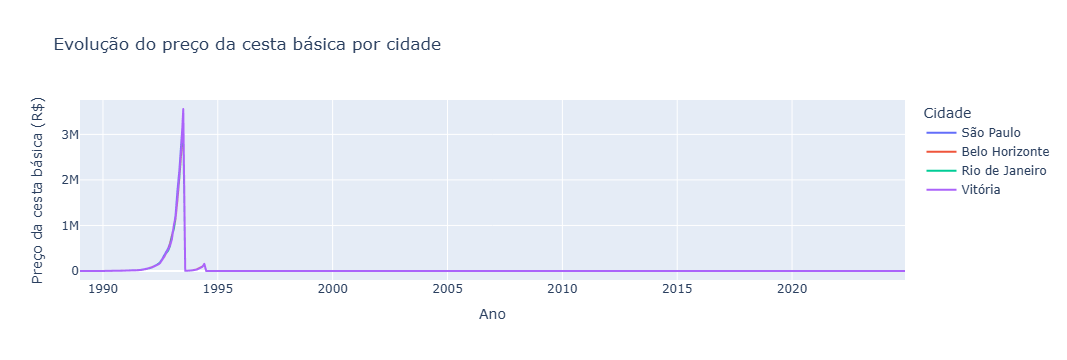

In [3]:
import plotly.express as px

fig_preco = px.line(
    precos,
    x="data",
    y="valor_reais",
    color="cidade",
    title="Evolução do preço da cesta básica por cidade",
    labels={
        "data": "Ano",
        "valor_reais": "Preço da cesta básica (R$)",
        "cidade": "Cidade"
    }
)

fig_preco.update_layout(
    xaxis_title="Ano",
    yaxis_title="Preço da cesta básica (R$)",
    legend_title="Cidade",
    hovermode="x unified"
)

fig_preco.show()

## Preço da cesta básica após a estabilização monetária

Para melhorar a leitura visual, a análise principal do preço da cesta básica considera o período de 1995 a 2024.

Esse recorte reduz o efeito visual da hiperinflação do início dos anos 1990 e permite comparar melhor a evolução dos preços entre as capitais analisadas.

O gráfico mostra a tendência de crescimento nominal do preço da cesta básica ao longo do tempo, com aceleração mais evidente a partir de 2020.

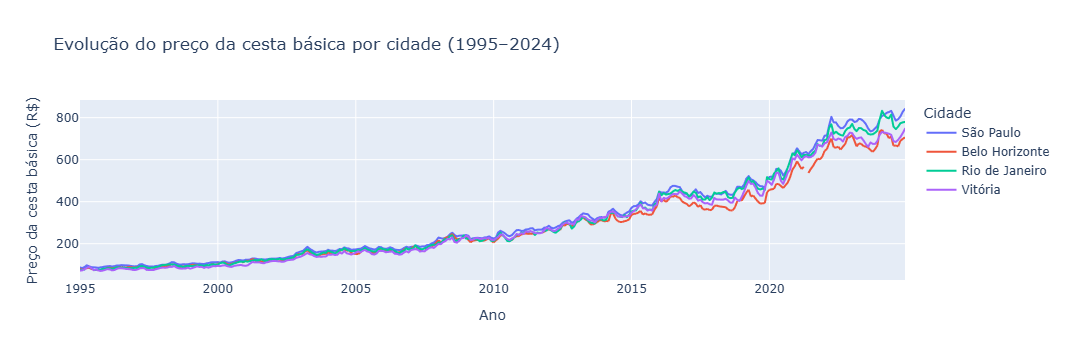

In [4]:
precos_pos_1995 = precos[precos["ano"] >= 1995].copy()

fig_preco_pos_1995 = px.line(
    precos_pos_1995,
    x="data",
    y="valor_reais",
    color="cidade",
    title="Evolução do preço da cesta básica por cidade (1995–2024)",
    labels={
        "data": "Ano",
        "valor_reais": "Preço da cesta básica (R$)",
        "cidade": "Cidade"
    }
)

fig_preco_pos_1995.update_layout(
    xaxis_title="Ano",
    yaxis_title="Preço da cesta básica (R$)",
    legend_title="Cidade",
    hovermode="x unified"
)

fig_preco_pos_1995.show()

## Horas de trabalho necessárias para aquisição da cesta básica

Além do preço nominal, o projeto analisa o tempo de trabalho necessário para comprar a cesta básica.

Esse indicador é importante porque aproxima a análise do poder de compra do trabalhador. Enquanto o preço nominal mostra quanto a cesta custa em reais, o tempo de trabalho ajuda a visualizar o esforço necessário para sua aquisição.

No período analisado, observa-se uma queda importante nas horas necessárias entre 1995 e meados dos anos 2000, seguida por maior estabilidade e nova elevação a partir de 2020.

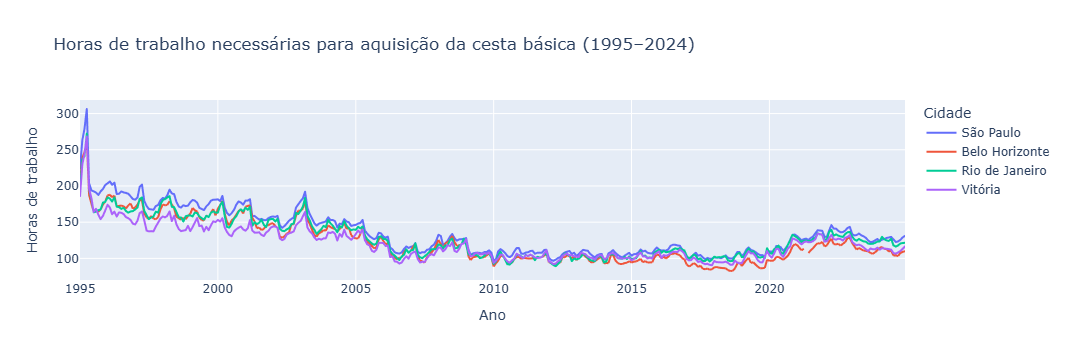

In [5]:
horas_pos_1995 = horas[horas["ano"] >= 1995].copy()

fig_horas_pos_1995 = px.line(
    horas_pos_1995,
    x="data",
    y="horas_decimal",
    color="cidade",
    title="Horas de trabalho necessárias para aquisição da cesta básica (1995–2024)",
    labels={
        "data": "Ano",
        "horas_decimal": "Horas de trabalho",
        "cidade": "Cidade"
    }
)

fig_horas_pos_1995.update_layout(
    xaxis_title="Ano",
    yaxis_title="Horas de trabalho",
    legend_title="Cidade",
    hovermode="x unified"
)

fig_horas_pos_1995.show()

## Exportação dos gráficos

Os gráficos principais são exportados em formato HTML para a pasta `outputs/charts/`.

Esse formato preserva a interatividade dos gráficos gerados com Plotly, permitindo abrir os resultados diretamente no navegador ou reutilizá-los futuramente na interface web do projeto.

In [6]:
CHARTS_PATH = PROJECT_ROOT / "outputs" / "charts"
CHARTS_PATH.mkdir(parents=True, exist_ok=True)

fig_preco_pos_1995.write_html(CHARTS_PATH / "preco_cesta_1995_2024.html")
fig_horas_pos_1995.write_html(CHARTS_PATH / "horas_trabalho_1995_2024.html")

print("Gráficos exportados para:")
print(CHARTS_PATH / "preco_cesta_1995_2024.html")
print(CHARTS_PATH / "horas_trabalho_1995_2024.html")

Gráficos exportados para:
C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\outputs\charts\preco_cesta_1995_2024.html
C:\Users\enzo.going\Documents\GitHub\analise-cesta-basica-brasil\outputs\charts\horas_trabalho_1995_2024.html


## Resumo comparativo do último mês disponível

Para complementar os gráficos temporais, esta etapa apresenta uma comparação entre as capitais no último mês disponível da base.

A tabela combina o preço nominal da cesta básica com o indicador de horas de trabalho necessárias para sua aquisição, permitindo observar quais cidades apresentaram maior custo e maior esforço de compra no recorte mais recente.

In [8]:
# Resumo comparativo do último mês disponível

ultimo_mes = precos["data"].max()

precos_ultimo = precos[precos["data"] == ultimo_mes][
    ["cidade", "valor_reais"]
].rename(columns={"valor_reais": "preco_cesta_reais"})

horas_ultimo = horas[horas["data"] == ultimo_mes][
    ["cidade", "horas_decimal"]
].rename(columns={"horas_decimal": "horas_trabalho"})

resumo_ultimo = precos_ultimo.merge(horas_ultimo, on="cidade")

resumo_ultimo["preco_cesta_reais"] = resumo_ultimo["preco_cesta_reais"].round(2)
resumo_ultimo["horas_trabalho"] = resumo_ultimo["horas_trabalho"].round(2)

resumo_ultimo = resumo_ultimo.sort_values("preco_cesta_reais", ascending=False)

print(f"Resumo comparativo do último mês disponível: {ultimo_mes.strftime('%m-%Y')}")
display(resumo_ultimo)

Resumo comparativo do último mês disponível: 12-2024


,cidade,preco_cesta_reais,horas_trabalho
0,São Paulo,841.29,131.08
2,Rio de Janeiro,779.84,121.50
3,Vitória,747.42,116.45
1,Belo Horizonte,706.32,110.05


## Conclusões preliminares

A análise mostra que o preço nominal da cesta básica apresenta tendência de crescimento ao longo do período pós-1995 nas quatro capitais analisadas.

O gráfico de preço indica uma aceleração mais evidente a partir de 2020, com aumento expressivo nos valores da cesta básica. No último mês disponível da base, São Paulo aparece com o maior preço nominal entre as capitais analisadas.

O indicador de horas de trabalho oferece uma leitura mais próxima do poder de compra. Entre 1995 e meados dos anos 2000, houve redução importante no tempo necessário para aquisição da cesta. A partir de 2020, porém, observa-se nova elevação desse indicador, sugerindo aumento do esforço necessário para compra da cesta básica.

No recorte mais recente, São Paulo também apresentou o maior número de horas de trabalho necessárias, enquanto Belo Horizonte apresentou os menores valores entre as cidades analisadas.

Esses resultados reforçam a importância de analisar não apenas o preço nominal dos alimentos, mas também indicadores relacionados ao poder de compra do trabalhador.